<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-use-of-chatgpt-reddit-insights-ml?scriptVersionId=250764958" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/how-students-use-chatgpt-filtered-reddit-dataset/filtered_student_chatgpt_reddit.csv


##  Title:
Student Use of ChatGPT – Reddit Insights

## Description:
This dataset contains filtered Reddit posts and comments related to how students use ChatGPT. It captures discussions from various subreddits where students share their experiences, study techniques, academic use cases, ethical concerns, productivity tips, and challenges faced while using ChatGPT. The data has been cleaned and curated to focus specifically on student-related content, offering insights into real-world educational applications of AI. This dataset can be used for sentiment analysis, topic modeling, behavior analysis, or educational research involving generative AI tools in learning environments.










## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/how-students-use-chatgpt-filtered-reddit-dataset/filtered_student_chatgpt_reddit.csv')

In [3]:
df.head()

,subreddit,body,controversiality,score,Unnamed: 0,comment_id,comment_parent_id,comment_body,Topic,Tag
0,gaming,it's pretty well known and it was a paid produ...,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
1,relationship_advice,i would actually just like to say that there a...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,news,the character 令 does bear a meaning similar to...,0.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
3,SquaredCircle,wrong. young footballers to this day help arou...,0.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN
4,news,"thanks for the interesting response, this shed...",0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,subreddit,body,controversiality,score,Unnamed: 0,comment_id,comment_parent_id,comment_body,Topic,Tag
448015,NaN,it's all in the level of skill it takes.\n\npr...,NaN,-208.0,NaN,NaN,NaN,NaN,8.0,Work
448016,NaN,it's all in the level of skill it takes.\n\npr...,NaN,-208.0,NaN,NaN,NaN,NaN,8.0,Work
448017,NaN,not really. [this alone is not a fireable offe...,NaN,-243.0,NaN,NaN,NaN,NaN,30.0,Gender
448018,NaN,according to what exactly? doxxing by itself i...,NaN,-300.0,NaN,NaN,NaN,NaN,9.0,Arg
448019,NaN,this is a last ditch effort to give my band's ...,NaN,-334.0,NaN,NaN,NaN,NaN,3.0,Teenage


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448020 entries, 0 to 448019
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   subreddit          12202 non-null   object 
 1   body               448020 non-null  object 
 2   controversiality   12202 non-null   float64
 3   score              448020 non-null  float64
 4   Unnamed: 0         0 non-null       float64
 5   comment_id         0 non-null       float64
 6   comment_parent_id  0 non-null       float64
 7   comment_body       0 non-null       float64
 8   Topic              435818 non-null  float64
 9   Tag                435818 non-null  object 
dtypes: float64(7), object(3)
memory usage: 34.2+ MB


In [6]:
df.describe()

,controversiality,score,Unnamed: 0,comment_id,comment_parent_id,comment_body,Topic
count,12202.000000,448020.000000,0.0,0.0,0.0,0.0,435818.000000
mean,0.040567,7.608529,NaN,NaN,NaN,NaN,16.034195
std,0.197293,86.106026,NaN,NaN,NaN,NaN,9.759459
min,0.000000,-889.000000,NaN,NaN,NaN,NaN,0.000000
25%,0.000000,1.000000,NaN,NaN,NaN,NaN,8.000000
50%,0.000000,2.000000,NaN,NaN,NaN,NaN,17.000000
75%,0.000000,3.000000,NaN,NaN,NaN,NaN,22.000000
max,1.000000,22159.000000,NaN,NaN,NaN,NaN,39.000000


In [7]:
df.isnull().sum()

subreddit            435818
body                      0
controversiality     435818
score                     0
Unnamed: 0           448020
comment_id           448020
comment_parent_id    448020
comment_body         448020
Topic                 12202
Tag                   12202
dtype: int64

In [8]:
df.duplicated().sum()

34038

In [9]:
df.dtypes

subreddit             object
body                  object
controversiality     float64
score                float64
Unnamed: 0           float64
comment_id           float64
comment_parent_id    float64
comment_body         float64
Topic                float64
Tag                   object
dtype: object

In [10]:
df.shape

(448020, 10)

In [11]:
df.columns

Index(['subreddit', 'body', 'controversiality', 'score', 'Unnamed: 0',
       'comment_id', 'comment_parent_id', 'comment_body', 'Topic', 'Tag'],
      dtype='object')

## Data visualizations

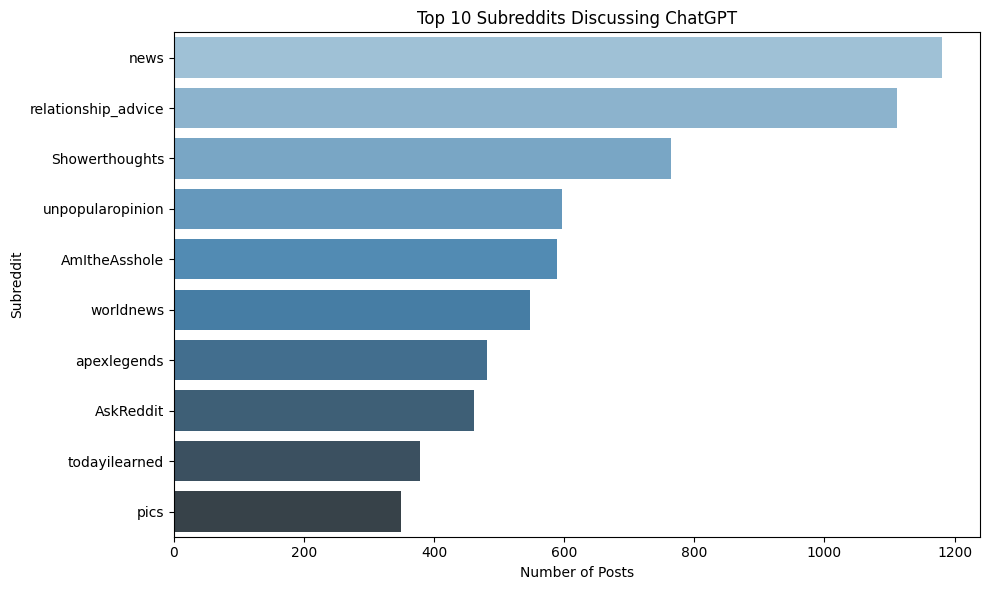

In [12]:
# Count posts per subreddit
subreddit_counts = df['subreddit'].value_counts().head(10)

# Bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=subreddit_counts.values, y=subreddit_counts.index, palette='Blues_d')
plt.title('Top 10 Subreddits Discussing ChatGPT')
plt.xlabel('Number of Posts')
plt.ylabel('Subreddit')
plt.tight_layout()
plt.show()

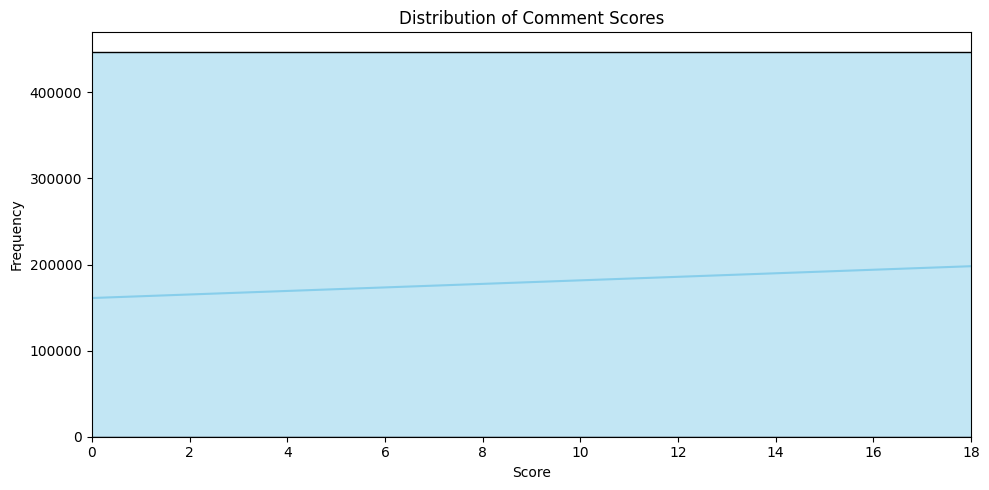

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Comment Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.xlim(0, df['score'].quantile(0.95))  # limit outliers
plt.tight_layout()
plt.show()


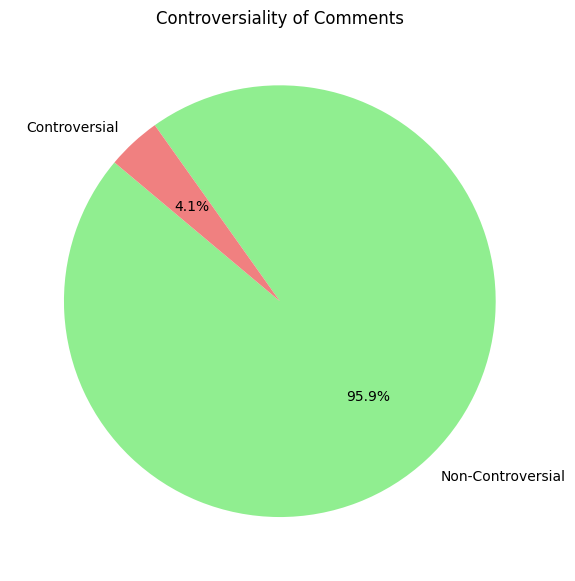

In [14]:
controversial_counts = df['controversiality'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(controversial_counts, labels=['Non-Controversial', 'Controversial'], 
        autopct='%1.1f%%', startangle=140, colors=['lightgreen', 'lightcoral'])
plt.title('Controversiality of Comments')
plt.tight_layout()
plt.show()


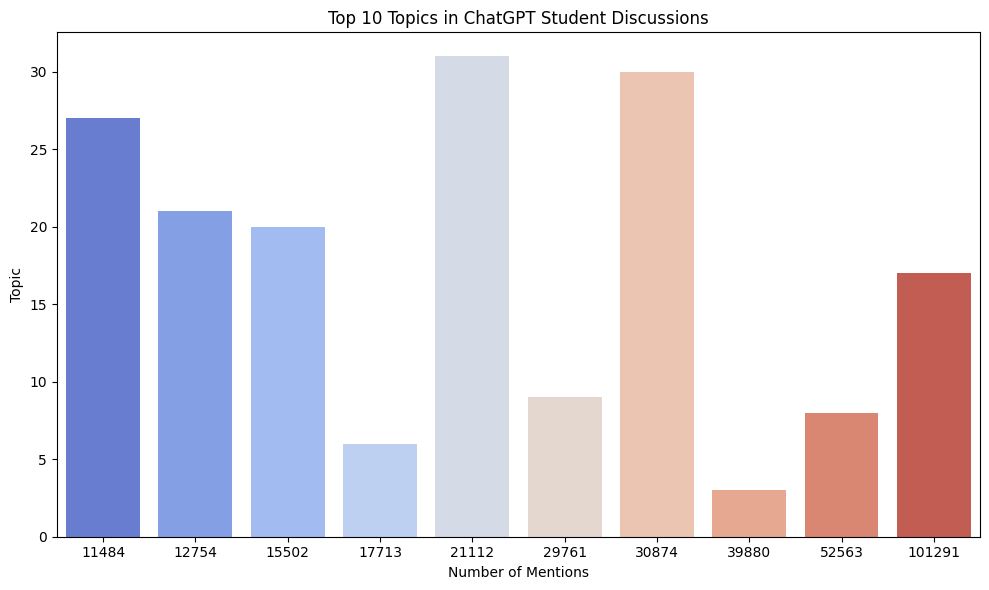

In [15]:
topic_counts = df['Topic'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=topic_counts.index, x=topic_counts.values, palette='coolwarm')
plt.title('Top 10 Topics in ChatGPT Student Discussions')
plt.xlabel('Number of Mentions')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()


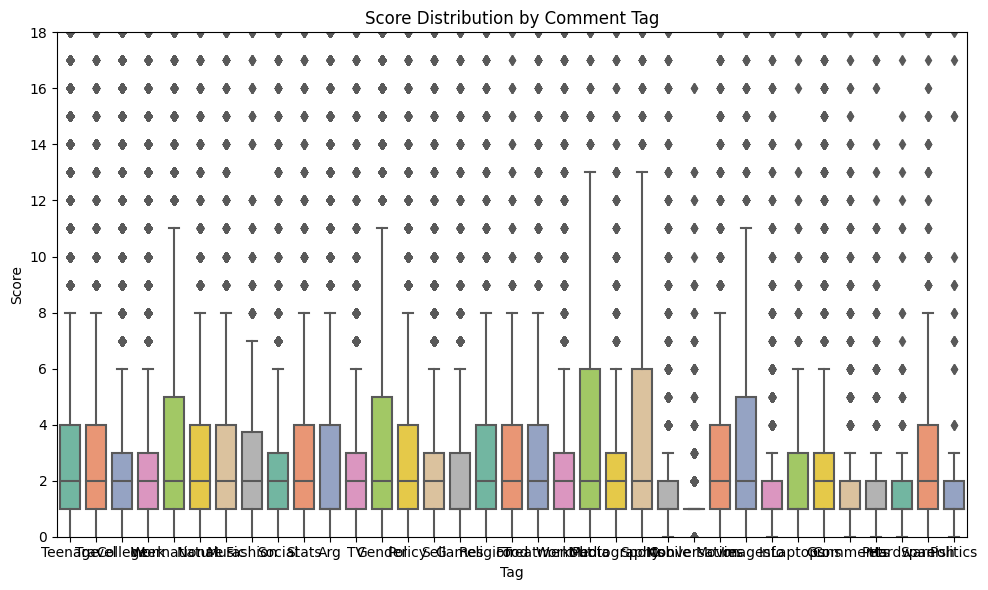

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tag', y='score', palette='Set2')
plt.title('Score Distribution by Comment Tag')
plt.xlabel('Tag')
plt.ylabel('Score')
plt.ylim(0, df['score'].quantile(0.95))  # trim outliers
plt.tight_layout()
plt.show()


## Thank you ..pls upvote!!